In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [2]:

# Load the Titanic dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic = pd.read_csv(url)


In [31]:

# Exploring missing values
titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [32]:
missing = titanic.isnull().sum()
missing = missing[missing > 0]
print(missing)

Age         177
Cabin       687
Embarked      2
dtype: int64


In [33]:
missing_percent = (titanic.isnull().sum() / len(titanic)) * 100
missing_percent = missing_percent[missing_percent > 0]

print(missing_percent)

Age         19.865320
Cabin       77.104377
Embarked     0.224467
dtype: float64


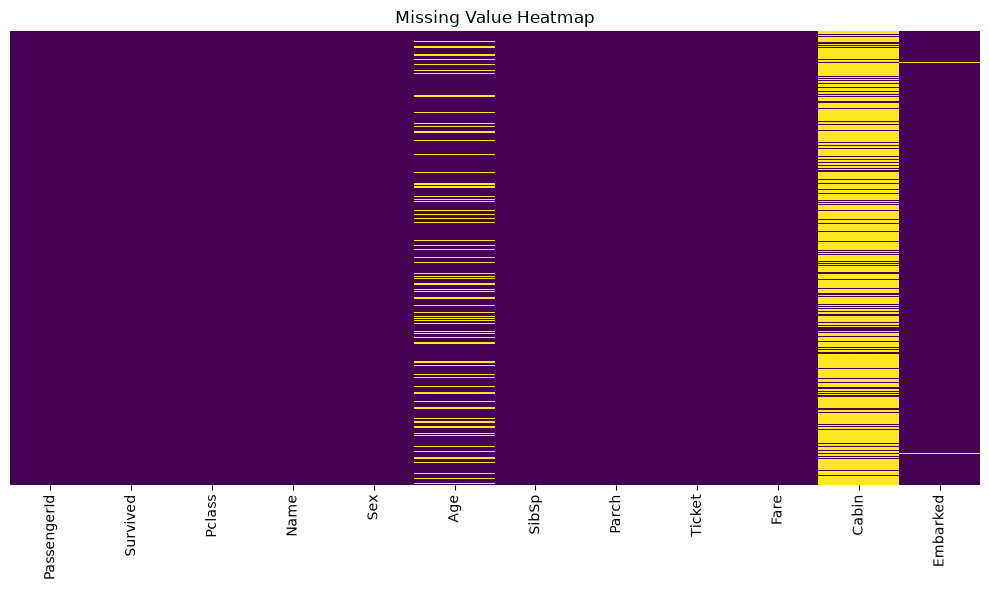

In [34]:

# Visualize missing values
plt.figure(figsize=(10, 6))
sns.heatmap(titanic.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Value Heatmap')
plt.tight_layout()
plt.show()

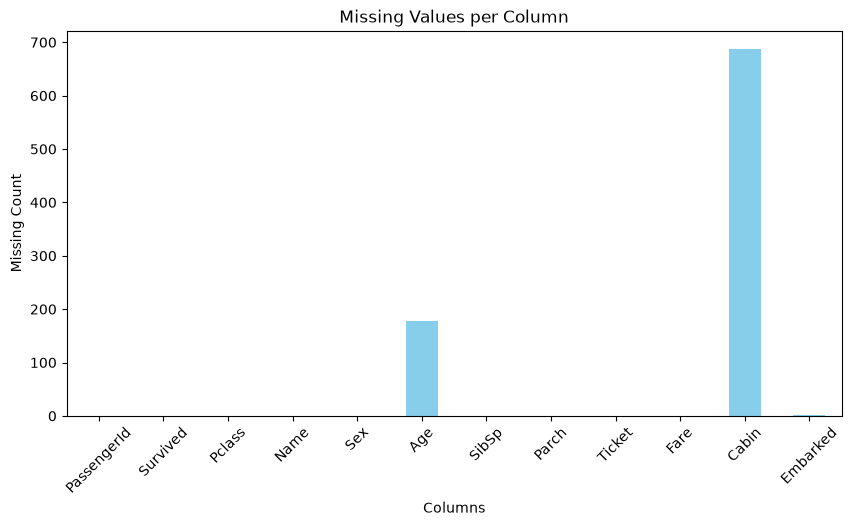

In [35]:
missing = titanic.isnull().sum()

plt.figure(figsize=(10,5))
missing.plot(kind='bar', color='skyblue')

plt.title("Missing Values per Column")
plt.xlabel("Columns")
plt.ylabel("Missing Count")
plt.xticks(rotation=45)

plt.show()

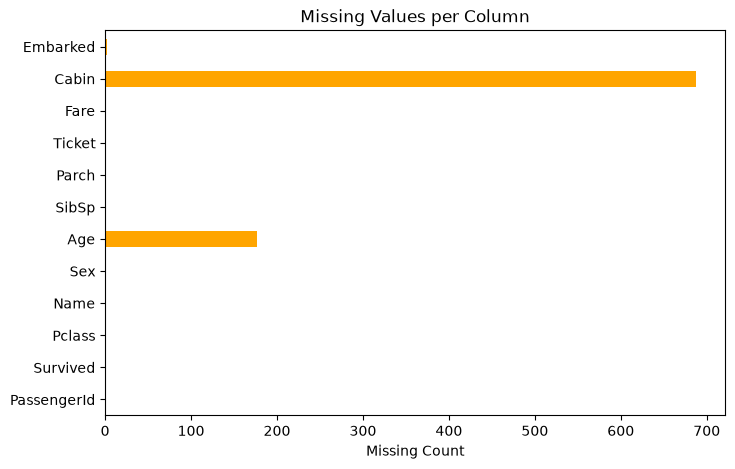

In [36]:
missing = titanic.isnull().sum()

plt.figure(figsize=(8,5))
missing.plot(kind='barh', color='orange')

plt.title("Missing Values per Column")
plt.xlabel("Missing Count")

plt.show()

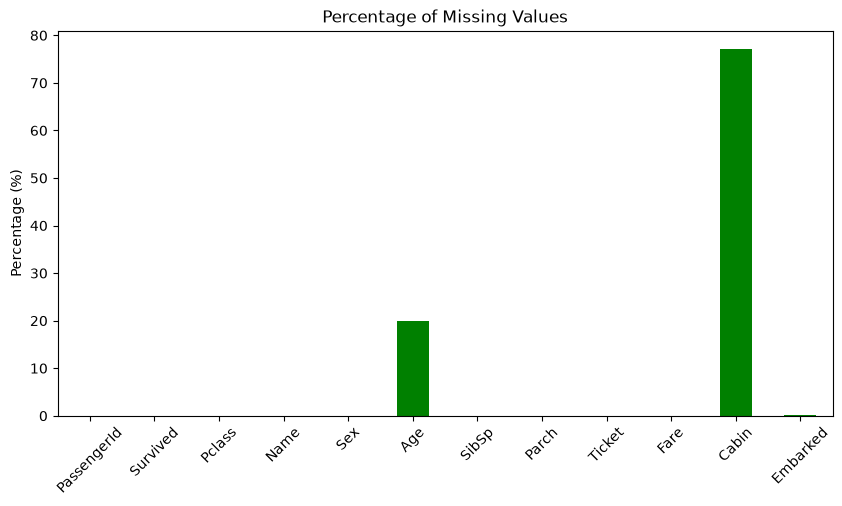

In [37]:
missing_percent = (titanic.isnull().sum()/len(titanic))*100

plt.figure(figsize=(10,5))
missing_percent.plot(kind='bar', color='green')

plt.title("Percentage of Missing Values")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)

plt.show()

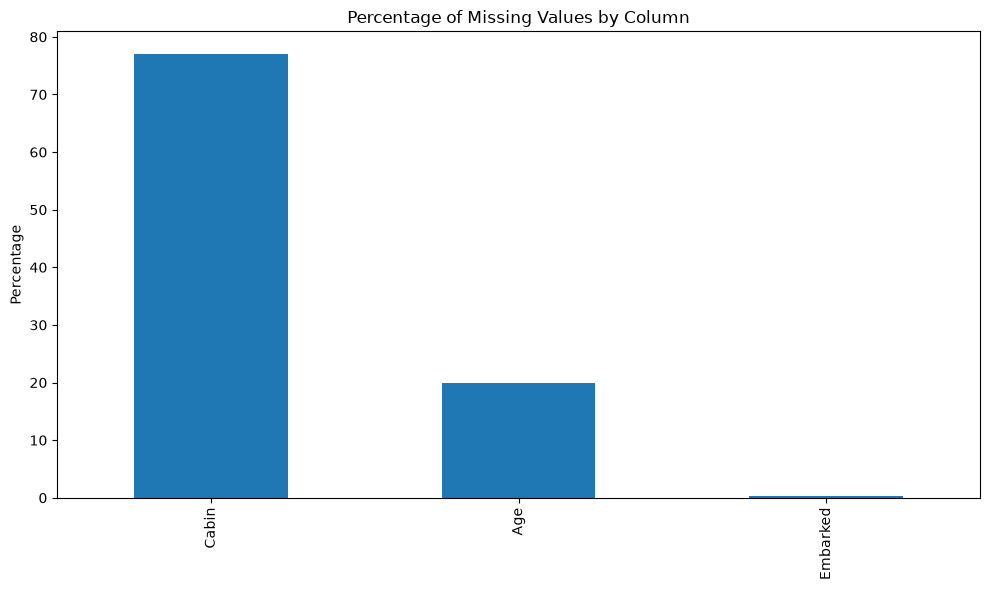

In [38]:
# Calculate percentage of missing values per column
missing_percentage = titanic.isnull().mean() * 100
missing_percentage = missing_percentage[missing_percentage > 0].sort_values(ascending=False)
plt.figure(figsize=(10, 6))
missing_percentage.plot(kind='bar')
plt.title('Percentage of Missing Values by Column')
plt.ylabel('Percentage')
plt.tight_layout()
plt.show()

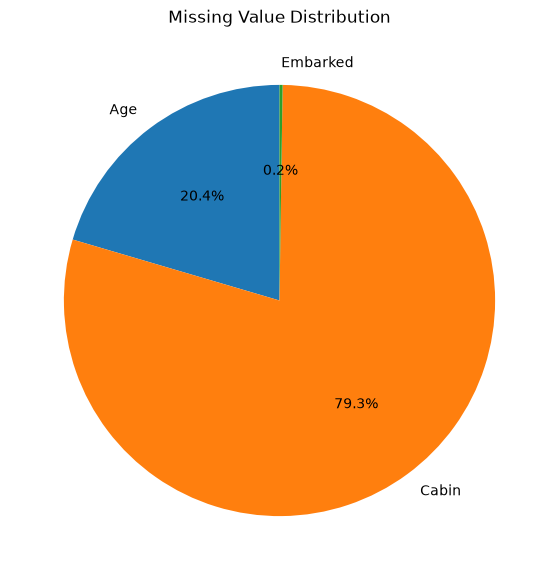

In [39]:
missing = titanic.isnull().sum()
missing = missing[missing > 0]

plt.figure(figsize=(7,7))
plt.pie(missing,
        labels=missing.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Missing Value Distribution")
plt.show()

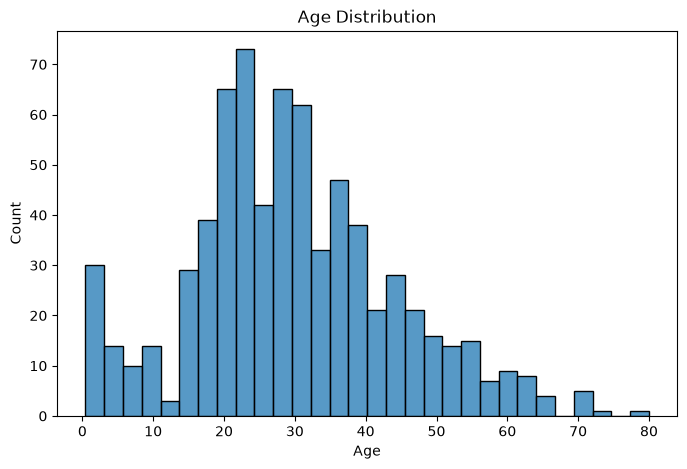

In [40]:
plt.figure(figsize=(8,5))
sns.histplot(titanic['Age'], bins=30)

plt.title("Age Distribution")
plt.show()

# HANDLING MISSING VALUES

In [42]:
# 1. Deletion approach - not always recommended but useful for some columns
titanic_reduced = titanic.drop(['Cabin', 'Ticket'], axis=1)  # High missingness or less relevant

In [47]:
# 2. Simple imputation for Age (using median grouped by Pclass)
age_imputed = titanic_reduced.copy()
age_imputed['Age'] = age_imputed.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))

In [48]:
# Calculate median Age for each passenger class
age_median_by_class = titanic.groupby('Pclass')['Age'].median()

print(age_median_by_class)

Pclass
1    37.0
2    29.0
3    24.0
Name: Age, dtype: float64


In [49]:

# 3. Create missing indicator for Age
age_imputed['Age_Missing'] = titanic_reduced['Age'].isnull().astype(int)

In [50]:
# 4. Mode imputation for categorical column (Embarked)
age_imputed['Embarked'] = age_imputed['Embarked'].fillna(age_imputed['Embarked'].mode()[0])

In [51]:
# Verify imputation results
age_imputed.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
Age_Missing    0
dtype: int64

Text(0.5, 1.0, 'Original Age Distribution')

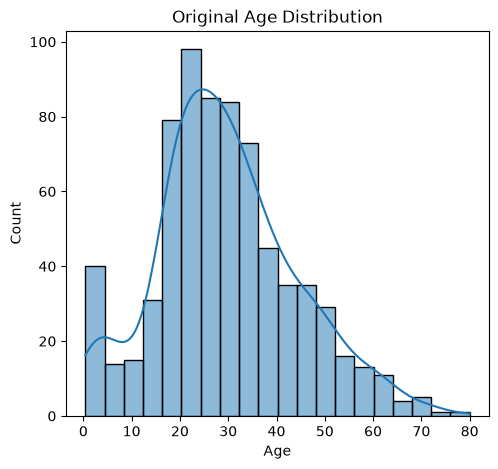

In [52]:
# Visualize Age distribution before and after imputation
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(titanic['Age'].dropna(), kde=True)
plt.title('Original Age Distribution')

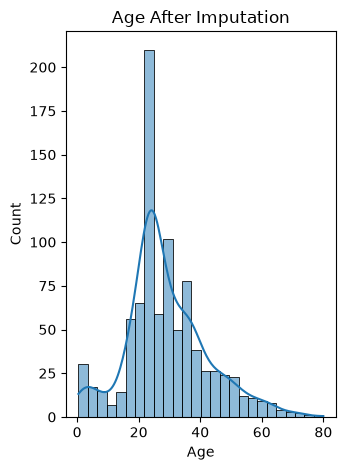

In [53]:
plt.subplot(1, 2, 2)
sns.histplot(age_imputed['Age'], kde=True)
plt.title('Age After Imputation')
plt.tight_layout()
plt.show()

# FEATURE SCALING

In [54]:
# Select relevant columns and prepare a dataset for ML
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
target = 'Survived'
X = age_imputed[features]
y = age_imputed[target]

In [55]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [68]:
# 1. Standardization (z-score normalization)
scaler = StandardScaler()
# Never directly transform your entire dataset - only fit on training data
numeric_features = ['Age', 'Fare']
X_train_std = X_train.copy()
X_test_std = X_test.copy()

X_train_std[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_std[numeric_features] = scaler.transform(X_test[numeric_features])

In [70]:
features = ['Age', 'Fare']

scaler = StandardScaler()

titanic[features] = scaler.fit_transform(titanic[features])

print(titanic[features].head())

        Age      Fare
0 -0.530377 -0.502445
1  0.571831  0.786845
2 -0.254825 -0.488854
3  0.365167  0.420730
4  0.365167 -0.486337


In [71]:
# 2. Min-Max Scaling (normalization)
min_max_scaler = MinMaxScaler()
X_train_norm = X_train.copy()
X_test_norm = X_test.copy()

X_train_norm[numeric_features] = min_max_scaler.fit_transform(X_train[numeric_features])
X_test_norm[numeric_features] = min_max_scaler.transform(X_test[numeric_features])

In [72]:
features = ['Age', 'Fare']

scaler = MinMaxScaler()

titanic[features] = scaler.fit_transform(titanic[features])

print(titanic[features].head())

        Age      Fare
0  0.271174  0.014151
1  0.472229  0.139136
2  0.321438  0.015469
3  0.434531  0.103644
4  0.434531  0.015713


Text(0.5, 1.0, 'Original Fare Distribution')

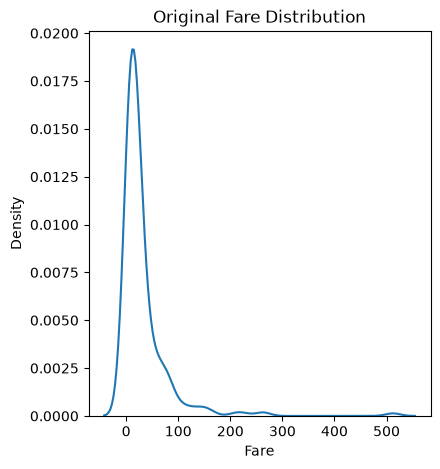

In [58]:
# Visualize scaling effects
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.kdeplot(X_train['Fare'], label='Original')
plt.title('Original Fare Distribution')

Text(0.5, 1.0, 'Standardized Fare')

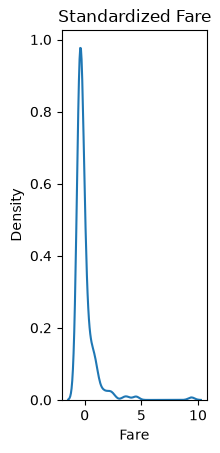

In [59]:
plt.subplot(1, 3, 2)
sns.kdeplot(X_train_std['Fare'], label='Standardized')
plt.title('Standardized Fare')

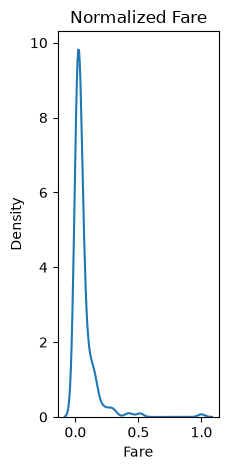

In [60]:
plt.subplot(1, 3, 3)
sns.kdeplot(X_train_norm['Fare'], label='Normalized')
plt.title('Normalized Fare')
plt.tight_layout()
plt.show()

# ENCODING CATEGORICAL VARIABLES

In [73]:
# 1. Label Encoding for ordinal features
label_encoder = LabelEncoder()
X_train_encoded = X_train_std.copy()
X_test_encoded = X_test_std.copy()

In [123]:
# Apply label encoding for Sex column
X_train_encoded['Sex'] = label_encoder.fit_transform(X_train_encoded['Sex'])
X_test_encoded['Sex'] = label_encoder.transform(X_test_encoded['Sex'])

In [75]:

# 2. One-Hot Encoding for nominal features
# Creating a one-hot encoder for 'Embarked'
embarked_ohe = OneHotEncoder(sparse_output=False, drop='first')
# Fit on training data
embarked_train_encoded = embarked_ohe.fit_transform(X_train_encoded[['Embarked']])
embarked_test_encoded = embarked_ohe.transform(X_test_encoded[['Embarked']])

In [76]:
# Create dataframes with the encoded columns
embarked_train_df = pd.DataFrame(
    embarked_train_encoded,
    columns=[f'Embarked_{c}' for c in embarked_ohe.categories_[0][1:]],
    index=X_train_encoded.index
)
embarked_test_df = pd.DataFrame(
    embarked_test_encoded,
    columns=[f'Embarked_{c}' for c in embarked_ohe.categories_[0][1:]],
    index=X_test_encoded.index
)

In [77]:

# Drop original Embarked column and join encoded columns
X_train_encoded = X_train_encoded.drop('Embarked', axis=1).join(embarked_train_df)
X_test_encoded = X_test_encoded.drop('Embarked', axis=1).join(embarked_test_df)


In [78]:
# Compare encoding methods
print("Label Encoded 'Sex':")
print(X_train_encoded['Sex'].value_counts())

Label Encoded 'Sex':
Sex
1    410
0    213
Name: count, dtype: int64


In [79]:
print("\nOne-Hot Encoded 'Embarked':")
print(X_train_encoded.filter(like='Embarked').head())


One-Hot Encoded 'Embarked':
     Embarked_Q  Embarked_S
445         0.0         1.0
650         0.0         1.0
172         0.0         1.0
450         0.0         1.0
314         0.0         1.0


# BUILDING PREPROCESSING PIPELINES

In [87]:
# Define preprocessing for numerical columns
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [88]:
features = [
    'Age',
    'Fare',
    'Pclass',
    'SibSp',
    'Parch',
    'Sex',
    'Embarked'
]

X = titanic[features]
y = titanic['Survived']

In [89]:
# Define preprocessing for categorical columns
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first'))
])

In [90]:
numeric_features = [
    'Age',
    'Fare',
    'Pclass',
    'SibSp',
    'Parch'
]


categorical_features = [
    'Sex',
    'Embarked'
]

In [91]:
numeric_pipeline = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='median')
        ),
        (
            'scaler',
            StandardScaler()
        )
    ]
)

In [92]:
SimpleImputer(strategy='median')

,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [93]:
categorical_pipeline = Pipeline(
    steps=[
        (
            'imputer',
            SimpleImputer(strategy='most_frequent')
        ),
        (
            'encoder',
            OneHotEncoder(handle_unknown='ignore')
        )
    ]
)

In [94]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            numeric_pipeline,
            numeric_features
        ),
        (
            'cat',
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [96]:
# Combine preprocessing steps
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numeric_features),
        ('cat', categorical_transformer, ['Sex', 'Embarked'])
    ])


In [97]:
# Create a full pipeline with preprocessing and model
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

In [98]:
# Reset to use raw features for complete pipeline demonstration
X = age_imputed[features]
y = age_imputed[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [99]:
# Train the pipeline
model_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Age','Fare','Pclass',...,'Parch','Sex','Embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining column

In [100]:
# Make predictions
predictions = model_pipeline.predict(X_test)

In [101]:
# Evaluate the model
print(f"Accuracy: {accuracy_score(y_test, predictions):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Accuracy: 0.8134

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.87      0.85       157
           1       0.80      0.73      0.76       111

    accuracy                           0.81       268
   macro avg       0.81      0.80      0.80       268
weighted avg       0.81      0.81      0.81       268



# ADVANCED: Custom Pipeline with Cross-Validation

In [102]:
from sklearn.model_selection import GridSearchCV

# Create a pipeline with multiple possible models
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier())
])

In [103]:
# Define parameters to search
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [None, 10],
    'preprocessor__num__imputer__strategy': ['mean', 'median'],
}

In [104]:
# Set up GridSearchCV
grid_search = GridSearchCV(pipeline, param_grid, cv=5,
                          scoring='accuracy', n_jobs=-1)

In [105]:
# Fit the grid search
grid_search.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [None, 10], 'classifier__n_estimators': [50, 100], 'preprocessor__num__imputer__strategy': ['mean', 'median']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable ad

In [106]:
# Best parameters and score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

Best parameters: {'classifier__max_depth': 10, 'classifier__n_estimators': 50, 'preprocessor__num__imputer__strategy': 'mean'}
Best cross-validation score: 0.8171


In [107]:
# Evaluate on test set
test_score = grid_search.score(X_test, y_test)
print(f"Test set score with best parameters: {test_score:.4f}")

Test set score with best parameters: 0.7948


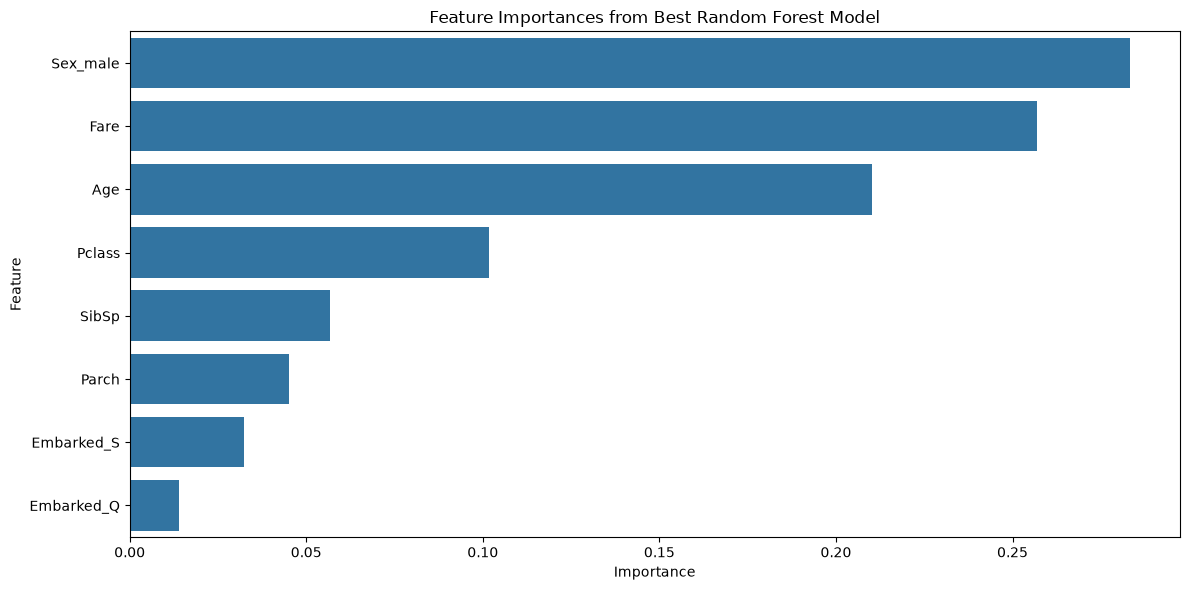

In [108]:
# BONUS: Feature importance from the best model
if hasattr(grid_search.best_estimator_.named_steps['classifier'], 'feature_importances_'):
    # Get the preprocessor
    preprocessor = grid_search.best_estimator_.named_steps['preprocessor']

    # Get the feature names after transformation
    ohe_features = preprocessor.transformers_[1][1].named_steps['onehot'].get_feature_names_out(['Sex', 'Embarked'])
    feature_names = np.concatenate([numeric_features, ohe_features])

    # Get feature importances
    importances = grid_search.best_estimator_.named_steps['classifier'].feature_importances_

    # Create a DataFrame for visualization
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    # Plot feature importances
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Importance', y='Feature', data=importance_df)
    plt.title('Feature Importances from Best Random Forest Model')
    plt.tight_layout()
    plt.show()

# Excercise

# Week 3 Day 1: Titanic Data Preprocessing & Modeling

In this exercise you'll reinforce:

- **Missing‑value exploration & visualization**  
- **Imputation strategies** (deletion, group‑median, mode, missing indicator)  
- **Feature scaling** (StandardScaler vs MinMaxScaler)  
- **Categorical encoding** (LabelEncoder, OneHotEncoder)  
- **Building end‑to‑end pipelines** with `ColumnTransformer` + `Pipeline`  
- **Model training & evaluation** (LogisticRegression, RandomForest)  
- **Hyperparameter tuning** via `GridSearchCV`  
- **Feature importance** extraction  

> **Instructions:**  
> 1. Don’t modify cells above the first `# TODO`.  
> 2. Replace each `# TODO` with your code.  
> 3. Run cells sequentially and verify each output.  
> 4. Wherever requested, add a brief comment on what you observe.

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1.1 Load dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic = pd.read_csv(url)

# 1.2 How many missing values per column?
# TODO: Compute and display titanic.isnull().sum()

# 1.3 Visualize missingness with a heatmap
plt.figure(figsize=(10,6))
# TODO: use sns.heatmap(...) to show where data is missing

# 1.4 Percentage of missing values by column (bar plot)
# TODO: calculate percentage and plot as a bar chart


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

Missing values per column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


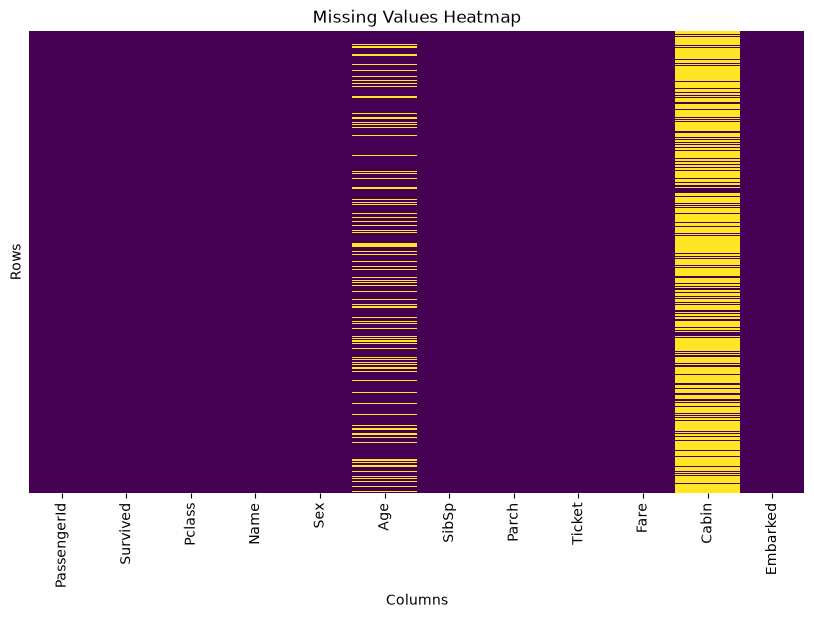

C:\Users\H P\AppData\Local\Temp\ipykernel_31148\647071931.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


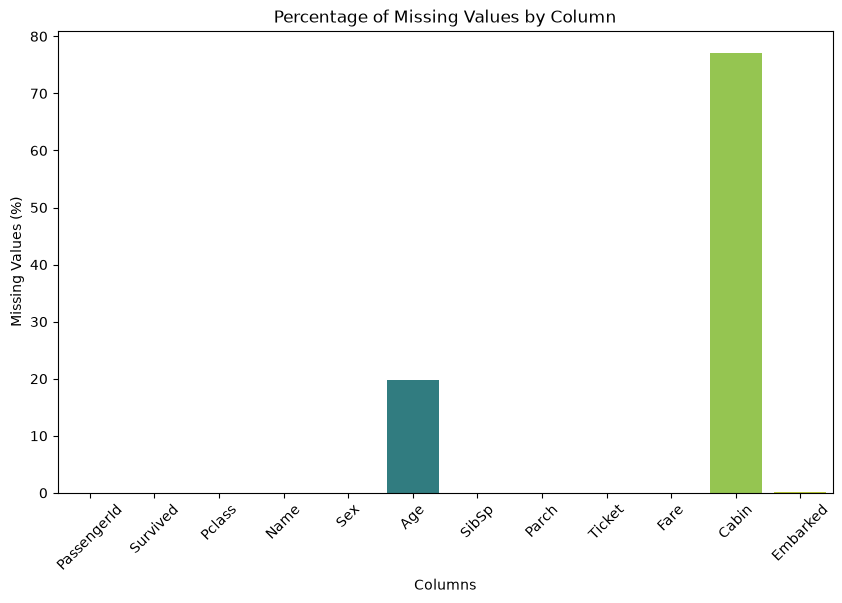

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1.1 Load dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic = pd.read_csv(url)

# 1.2 How many missing values per column?
missing_values = titanic.isnull().sum()
print("Missing values per column:")
print(missing_values)

# 1.3 Visualize missingness with a heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    titanic.isnull(),
    cmap="viridis",
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

# 1.4 Percentage of missing values by column (bar plot)

missing_percentage = (titanic.isnull().sum() / len(titanic)) * 100

plt.figure(figsize=(10,6))

sns.barplot(
    x=missing_percentage.index,
    y=missing_percentage.values,
    palette="viridis"
)

plt.title("Percentage of Missing Values by Column")
plt.xlabel("Columns")
plt.ylabel("Missing Values (%)")
plt.xticks(rotation=45)

plt.show()

Dataset Shape:
(891, 12)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB

Statistical Summary:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.69

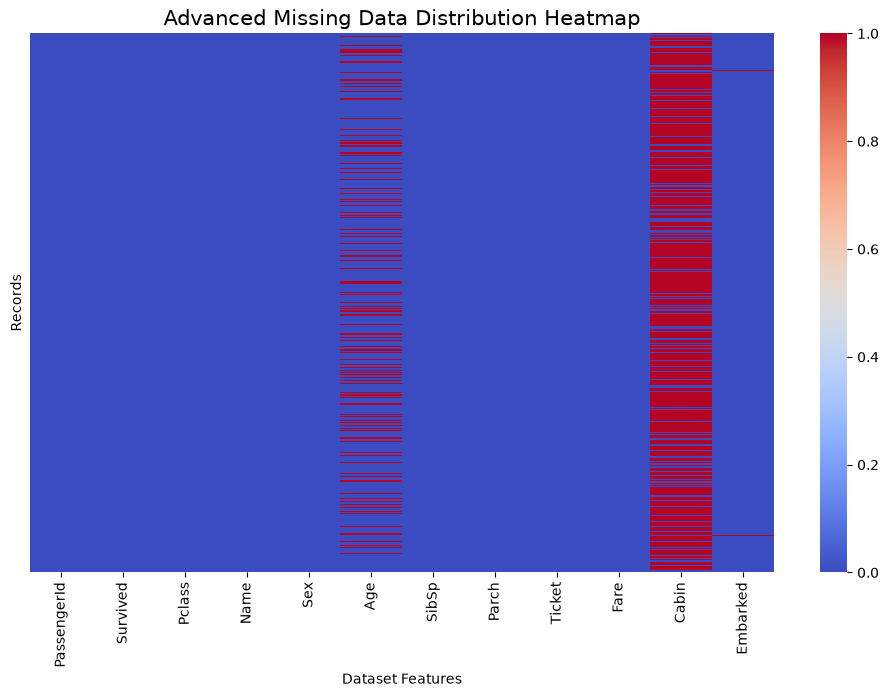

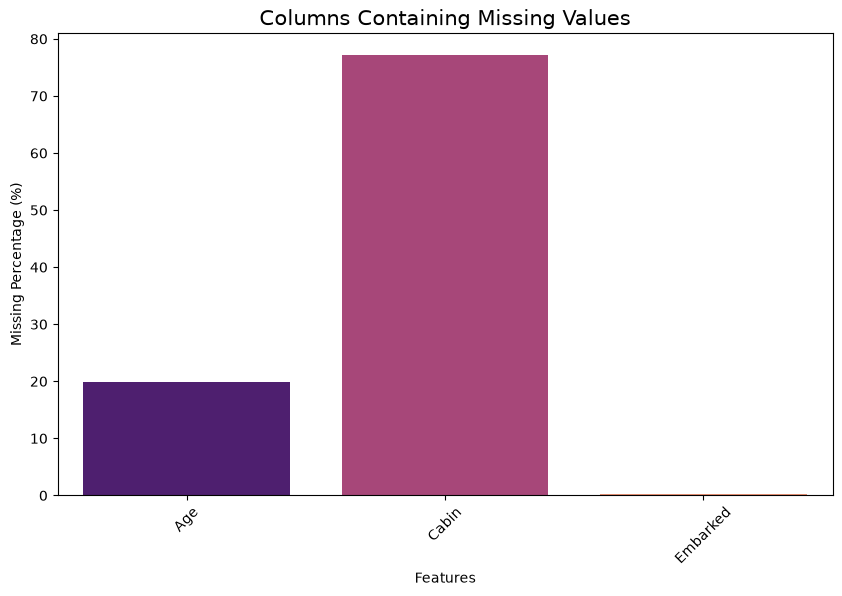


Missing Values Before and After Cleaning:
             Before Cleaning  After Cleaning
PassengerId                0               0
Survived                   0               0
Pclass                     0               0
Name                       0               0
Sex                        0               0
Age                      177             177
SibSp                      0               0
Parch                      0               0
Ticket                     0               0
Fare                       0               0
Cabin                    687             687
Embarked                   2               2
Final Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Cleaning Completed Successfully!


C:\Users\H P\AppData\Local\Temp\ipykernel_31148\3038138394.py:91: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data_cleaned[column].fillna(
C:\Users\H P\AppData\Local\Temp\ipykernel_31148\3038138394.py:98: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace meth

In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

titanic = pd.read_csv(url)
print("Dataset Shape:")
print(titanic.shape)

print("\nDataset Information:")
titanic.info()

print("\nStatistical Summary:")
print(titanic.describe())
missing_summary = pd.DataFrame({
    "Missing Count": titanic.isnull().sum(),
    "Missing Percentage": 
    (titanic.isnull().sum()/len(titanic))*100,
    "Data Type": titanic.dtypes
})
missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
]


print("\nMissing Value Summary:")
print(missing_summary)

plt.figure(figsize=(12,7))

sns.heatmap(
    titanic.isnull(),
    cmap="coolwarm",
    cbar=True,
    yticklabels=False
)

plt.title(
    "Advanced Missing Data Distribution Heatmap",
    fontsize=15
)

plt.xlabel("Dataset Features")
plt.ylabel("Records")

plt.show()
plt.figure(figsize=(10,6))


missing_percentage = (
    titanic.isnull().sum()
    /len(titanic)
)*100

missing_percentage = (
    missing_percentage[
        missing_percentage > 0
    ]
)
sns.barplot(
    x=missing_percentage.index,
    y=missing_percentage.values,
    hue=missing_percentage.index,
    palette="magma",
    legend=False
)
plt.title(
    "Columns Containing Missing Values",
    fontsize=15
)

plt.xlabel("Features")
plt.ylabel("Missing Percentage (%)")

plt.xticks(rotation=45)
plt.show()
data_cleaned = titanic.copy()


for column in data_cleaned.columns:

    if data_cleaned[column].isnull().sum() > 0:

        if data_cleaned[column].dtype in [
            "int64",
            "float64"
        ]:

            data_cleaned[column].fillna(
                data_cleaned[column].median(),
                inplace=True
            )

        else:

            data_cleaned[column].fillna(
                data_cleaned[column].mode()[0],
                inplace=True
            )

comparison = pd.DataFrame({

    "Before Cleaning":
    titanic.isnull().sum(),

    "After Cleaning":
    data_cleaned.isnull().sum()

})

print("\nMissing Values Before and After Cleaning:")
print(comparison)

print("Final Missing Values:")
print(data_cleaned.isnull().sum())

print("Cleaning Completed Successfully!")

2- Handle Missing Values ---

In [112]:
# Start from a copy
df = titanic.copy()

# 2.1 Drop columns with too many missing or irrelevant
# TODO: df = df.drop([...], axis=1)
df = titanic.copy()

# 2.1 Drop columns with too many missing or irrelevant data
df = df.drop(
    ['Cabin', 'PassengerId', 'Name', 'Ticket'],
    axis=1
)
# 2.2 Impute Age by median within each Pclass
# TODO: df['Age'] = df.groupby('Pclass')['Age'].transform(...)
df['Age'] = df.groupby('Pclass')['Age'].transform(
    lambda x: x.fillna(x.median())
)
# 2.3 Create Age_missing indicator column
# TODO: df['Age_Missing'] = ...
df['Age_Missing'] = titanic['Age'].isnull().astype(int)

# 2.4 Impute Embarked with mode
# TODO: df['Embarked'] = df['Embarked'].fillna(...)
df['Embarked'] = df['Embarked'].fillna(
    df['Embarked'].mode()[0]
)
# 2.5 Verify no more missing values
# TODO: df.isnull().sum()
missing_check = df.isnull().sum()

print("Missing values after preprocessing:")
print(missing_check)

Missing values after preprocessing:
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Embarked       0
Age_Missing    0
dtype: int64


3. Feature Scaling

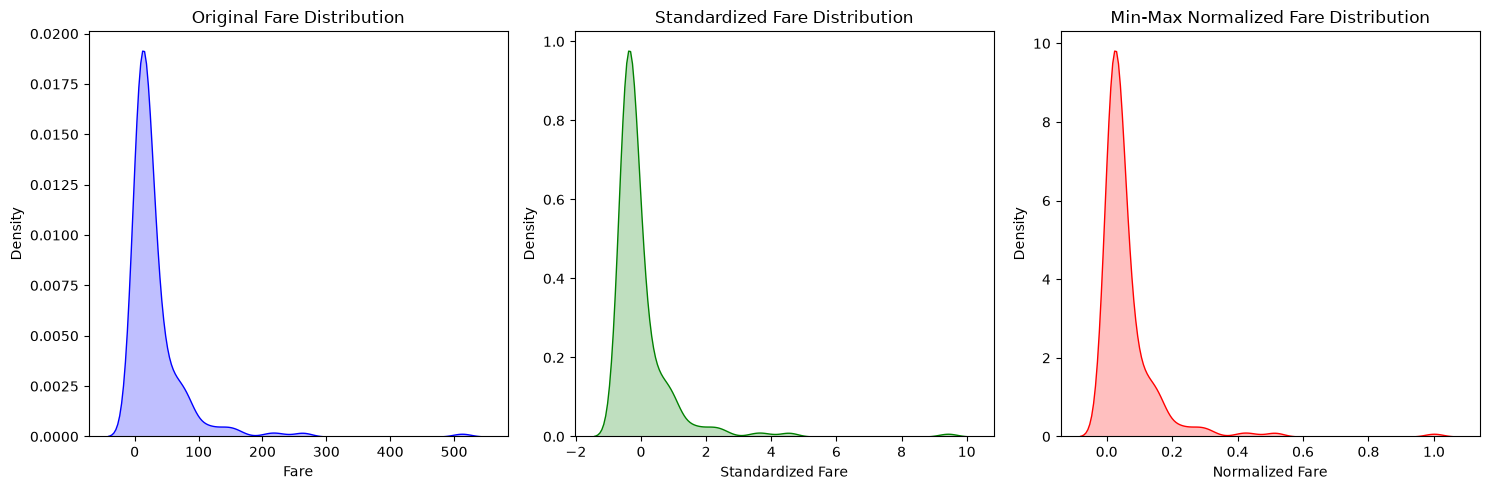

In [115]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

features = ['Age','Fare']
X = df[features]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3.1 Standardization
std = StandardScaler()
# TODO: fit on X_train, transform both X_train and X_test
std.fit(X_train)
X_train_std = std.transform(X_train)
X_test_std = std.transform(X_test)

X_train_std = pd.DataFrame(
    X_train_std,
    columns=features,
    index=X_train.index
)

X_test_std = pd.DataFrame(
    X_test_std,
    columns=features,
    index=X_test.index
)

# 3.2 Min‑Max normalization
mms = MinMaxScaler()
# TODO: fit on X_train, transform both X_train and X_test
mms.fit(X_train)

# Transform both training and testing data
X_train_mms = mms.transform(X_train)
X_test_mms = mms.transform(X_test)

# Convert back to DataFrame for readability
X_train_mms = pd.DataFrame(
    X_train_mms,
    columns=features,
    index=X_train.index
)

X_test_mms = pd.DataFrame(
    X_test_mms,
    columns=features,
    index=X_test.index
)

# 3.3 Plot distributions: original vs standardized vs normalized
plt.figure(figsize=(15,5))
# TODO: three subplots with sns.kdeplot for Fare in each dataset
plt.subplot(1,3,1)
sns.kdeplot(X_train['Fare'], fill=True, color='blue')
plt.title("Original Fare Distribution")
plt.xlabel("Fare")

# Standardized Fare distribution
plt.subplot(1,3,2)
sns.kdeplot(X_train_std['Fare'], fill=True, color='green')
plt.title("Standardized Fare Distribution")
plt.xlabel("Standardized Fare")

# Min-Max normalized Fare distribution
plt.subplot(1,3,3)
sns.kdeplot(X_train_mms['Fare'], fill=True, color='red')
plt.title("Min-Max Normalized Fare Distribution")
plt.xlabel("Normalized Fare")

plt.tight_layout()
plt.show()

4. Encode Categorical Features

In [117]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

X_cat = df[['Sex','Embarked']]

# 4.1 Label‑encode Sex
le = LabelEncoder()
# TODO: X_cat['Sex_le'] = ...
X_cat['Sex_le'] = le.fit_transform(X_cat['Sex'])

# 4.2 One‑hot encode Embarked (drop first)
ohe = OneHotEncoder(sparse_output=False, drop='first')
# TODO: fit_transform Embarked and create a DataFrame with new columns
embarked_encoded = ohe.fit_transform(
    X_cat[['Embarked']]
)

embarked_df = pd.DataFrame(
    embarked_encoded,
    columns=ohe.get_feature_names_out(['Embarked']),
    index=X_cat.index
)

# Display your encoded features
# TODO: print head of resulting DataFrame
encoded_features = pd.concat(
    [
        X_cat[['Sex_le']],
        embarked_df
    ],
    axis=1
)
print(encoded_features.head())


   Sex_le  Embarked_Q  Embarked_S
0       1         0.0         1.0
1       0         0.0         0.0
2       0         0.0         1.0
3       0         0.0         1.0
4       1         0.0         1.0


5. Build a Preprocessing + Model Pipeline



In [121]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 5.1 Define transformers
num_features = ['Age','Fare']
cat_features = ['Sex','Embarked']

num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first'))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

# 5.2 Create full pipeline with Logistic Regression
pipe = Pipeline([
    ('preproc', preprocessor),
    ('clf', LogisticRegression(max_iter=1000))
])

# 5.3 Split raw data and train
X_full = df[num_features + cat_features]
y_full = df['Survived']
X_tr, X_te, y_tr, y_te = train_test_split(X_full, y_full, test_size=0.3, random_state=42)

# TODO: fit pipe on X_tr, y_tr
# TODO: predict on X_te, compute accuracy and print classification_report
pipe.fit(X_tr, y_tr)
y_pred = pipe.predict(X_te)
accuracy = accuracy_score(y_te, y_pred)

print("Accuracy:", accuracy)

print("Classification Report:")
print(classification_report(y_te, y_pred))


Accuracy: 0.7798507462686567
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.82       157
           1       0.75      0.70      0.73       111

    accuracy                           0.78       268
   macro avg       0.77      0.77      0.77       268
weighted avg       0.78      0.78      0.78       268



6. Hyperparameter Tuning with GridSearchCV

Best Parameters:
{'clf__max_depth': 10, 'clf__n_estimators': 100, 'preproc__num__imputer__strategy': 'mean'}
Top 10 Important Features:
           Feature  Importance
1        num__Fare    0.372690
2    cat__Sex_male    0.304935
0         num__Age    0.277557
4  cat__Embarked_S    0.031333
3  cat__Embarked_Q    0.013485


C:\Users\H P\AppData\Local\Temp\ipykernel_31148\3060530287.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


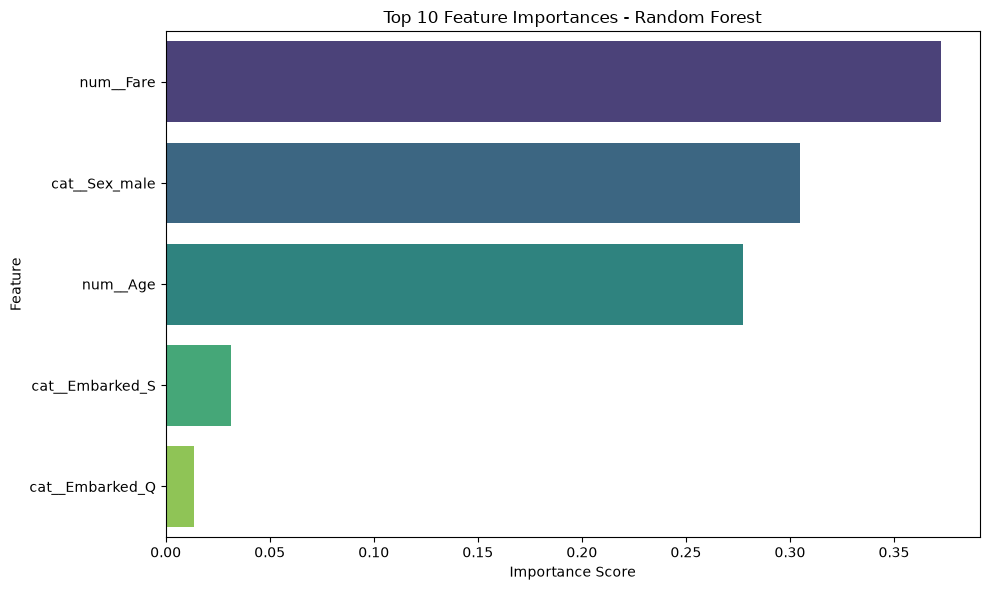

In [122]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 6.1 Replace classifier in pipeline
tune_pipe = Pipeline([
    ('preproc', preprocessor),
    ('clf', RandomForestClassifier(random_state=42))
])

# 6.2 Set up parameter grid
param_grid = {
    'clf__n_estimators': [50, 100],
    'clf__max_depth': [None, 10],
    'preproc__num__imputer__strategy': ['mean','median']
}

grid = GridSearchCV(tune_pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# TODO: fit grid on X_tr, y_tr
# TODO: print best_params_ and best_score_

grid.fit(X_tr, y_tr)
print("Best Parameters:")
print(grid.best_params_)

# 6.3 Evaluate best estimator on test set
# TODO: grid.best_estimator_.score(X_te, y_te)
test_accuracy = grid.best_estimator_.score(
    X_te,
    y_te
)
# 6.4 (Bonus) If RandomForest gives feature_importances_, extract and plot the top 10
# Hint: use .named_steps['preproc'] to get transformer and get_feature_names_out

# 6.4 (Bonus) Feature Importance Extraction and Plot

best_rf = grid.best_estimator_.named_steps['clf']

preprocessor_fitted = grid.best_estimator_.named_steps['preproc']

feature_names = preprocessor_fitted.get_feature_names_out()
importances = best_rf.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

top10_features = feature_importance_df.head(10)

print("Top 10 Important Features:")
print(top10_features)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10_features,
    x='Importance',
    y='Feature',
    palette='viridis'
)

plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()
